# Final Enterprise Model Decision And End-to-End Contract

This notebook consolidates the complete controlled experiment using the model-building principles in *Forecasting: Theory and Practice*: preprocessing and outlier awareness, exogenous/domain features, cross-learning, statistical baselines, intermittent-demand methods, rolling-origin testing, formal forecast comparison, residual diagnosis, probabilistic calibration and explicit decision consequences.

**Decision:** the v8 champion is enterprise-quality as a validation harness and simulation model. It is not a production forecast model because its material identities, BOMs, production plans and history are generated.


In [1]:
from pathlib import Path
import json
import pandas as pd
try:
    from IPython.display import Image, display
except ImportError:
    class Image:
        def __init__(self, filename): self.filename = filename
        def __repr__(self): return f"Image({self.filename})"
    def display(value): print(value)
ROOT = Path.cwd()
if ROOT.name != "v8_controlled_synthetic_validation":
    candidate = ROOT / "Ai miroservices/modeling/v8_controlled_synthetic_validation"
    ROOT = candidate if candidate.exists() else ROOT
OUT = ROOT / "outputs"
PLOTS = OUT / "plots"
summary = json.loads((OUT / "run_summary.json").read_text())
model_card = json.loads((OUT / "model_card.json").read_text())
deployment = json.loads((OUT / "deployment_decision.json").read_text())
contract = json.loads((OUT / "integration_contract.json").read_text())


## 1. Research-Guideline Checklist

- Data lineage and generated-ground-truth flags are explicit.
- Target month `t` uses demand only through `t-1`.
- Production/BOM inputs are used only when assumed known at forecast creation time.
- Statistical, intermittent, deterministic and ML candidates share identical test rows.
- Hyperparameters are tuned before champion selection.
- Champion selection is separate from the untouched final test.
- Paired t, Wilcoxon and low-power monthly DM-style evidence are reported together.
- Residual normality, autocorrelation and heteroscedasticity are tested.
- Prediction intervals are calibrated outside the test window.
- Inventory policy obeys MOQ and order multiples.


In [2]:
leaderboard = pd.read_csv(OUT / "model_leaderboard.csv")
paired = pd.read_csv(OUT / "paired_model_tests.csv")
residual = pd.read_csv(OUT / "residual_tests.csv")
interval = pd.read_csv(OUT / "interval_calibration.csv")
display(leaderboard.assign(WAPE_pct=100*leaderboard.WAPE, Bias_pct=100*leaderboard.Bias).round(2))
display(paired.round(4))
display(residual)
display(interval)


,model,rows,materials,WAPE,MAE,RMSE,Bias,under_forecast_rate,shock_WAPE,WAPE_pct,Bias_pct
0,random_forest_causal,1440,120,0.08,728.12,1368.40,0.01,0.47,0.08,8.24,0.70
1,extra_trees_causal,1440,120,0.08,736.76,1408.46,-0.00,0.48,0.09,8.34,-0.15
2,bom_plan,1440,120,0.09,752.43,1347.60,0.02,0.42,0.08,8.51,1.84
3,lightgbm_causal_tweedie,1440,120,0.09,762.68,1530.02,-0.01,0.51,0.09,8.63,-0.72
4,lightgbm_causal_ratio,1440,120,0.09,809.94,1541.10,0.00,0.49,0.09,9.16,0.20
5,lightgbm_direct_ratio,1440,120,0.10,910.64,1662.40,0.00,0.48,0.10,10.30,0.12
6,holt_damped,1440,120,0.11,944.07,1798.70,-0.01,0.53,0.11,10.68,-1.21
7,seasonal_naive,1440,120,0.14,1203.55,2222.65,-0.06,0.62,0.17,13.62,-5.88
8,croston_sba,1440,120,0.15,1318.09,2583.60,-0.10,0.68,0.17,14.91,-9.65
9,moving_average_6,1440,120,0.15,1363.65,2519.72,-0.01,0.51,0.13,15.43,-1.24


,champion,candidate,paired_rows,mean_abs_error_delta,paired_t_statistic,paired_t_p_value,wilcoxon_statistic,wilcoxon_p_value,monthly_dm_style_statistic,monthly_dm_style_p_value,test_limit
0,extra_trees_causal,ridge_causal,1440,-2822.9292,-4.6744,0.0000,241310.0,0.0000,-7.6222,0.0000,DM-style test uses 12 monthly aggregate loss d...
1,extra_trees_causal,elastic_net_causal,1440,-2384.7493,-4.7029,0.0000,278456.0,0.0000,-7.2753,0.0000,DM-style test uses 12 monthly aggregate loss d...
2,extra_trees_causal,moving_average_6,1440,-626.8941,-16.0609,0.0000,211790.0,0.0000,-6.4758,0.0000,DM-style test uses 12 monthly aggregate loss d...
3,extra_trees_causal,croston_sba,1440,-581.3276,-13.5692,0.0000,253179.0,0.0000,-4.7333,0.0006,DM-style test uses 12 monthly aggregate loss d...
4,extra_trees_causal,seasonal_naive,1440,-466.7946,-13.8109,0.0000,249676.0,0.0000,-6.4820,0.0000,DM-style test uses 12 monthly aggregate loss d...
5,extra_trees_causal,holt_damped,1440,-207.3097,-9.1925,0.0000,339649.0,0.0000,-8.5358,0.0000,DM-style test uses 12 monthly aggregate loss d...
6,extra_trees_causal,lightgbm_direct_ratio,1440,-173.8782,-8.6620,0.0000,348171.0,0.0000,-6.8289,0.0000,DM-style test uses 12 monthly aggregate loss d...
7,extra_trees_causal,lightgbm_causal_ratio,1440,-73.1865,-4.4157,0.0000,432189.0,0.0000,-4.3724,0.0011,DM-style test uses 12 monthly aggregate loss d...
8,extra_trees_causal,lightgbm_causal_tweedie,1440,-25.9168,-1.4925,0.1358,507894.0,0.4912,-0.9916,0.3427,DM-style test uses 12 monthly aggregate loss d...
9,extra_trees_causal,bom_plan,1440,-15.6751,-0.9092,0.3634,460684.0,0.0002,-0.4871,0.6358,DM-style test uses 12 monthly aggregate loss d...


,test,statistic,p_value,null_hypothesis
0,Jarque-Bera normality,16208.048424,0.000000e+00,residuals are normally distributed
1,Ljung-Box monthly mean residual lag 4,4.571595,3.341423e-01,no residual autocorrelation
2,Breusch-Pagan,472.250888,1.037437e-104,constant residual variance
3,Spearman abs residual vs fitted,0.732158,4.442027e-242,no monotonic scale-error relationship


,model,nominal_coverage,empirical_coverage,normalized_error_quantile,average_interval_width,calibration_rows,test_rows
0,extra_trees_causal,0.9,0.920833,0.191629,3382.347528,720,1440


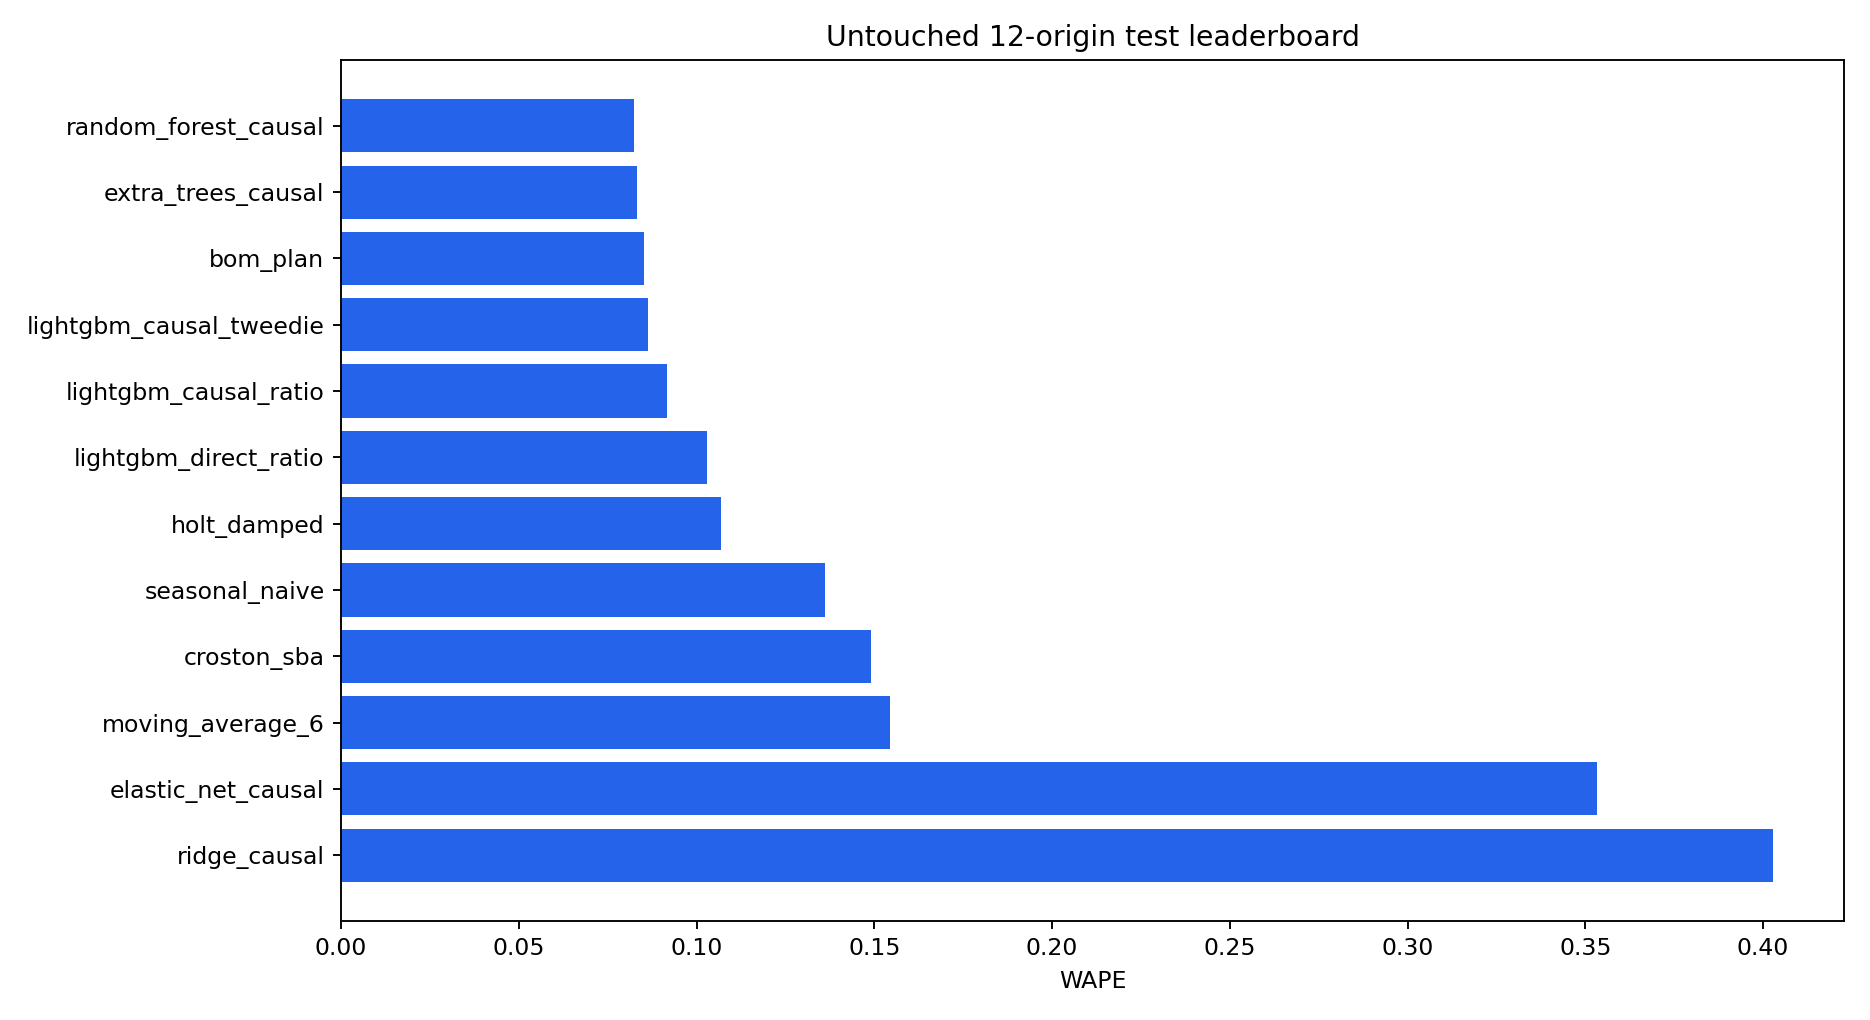

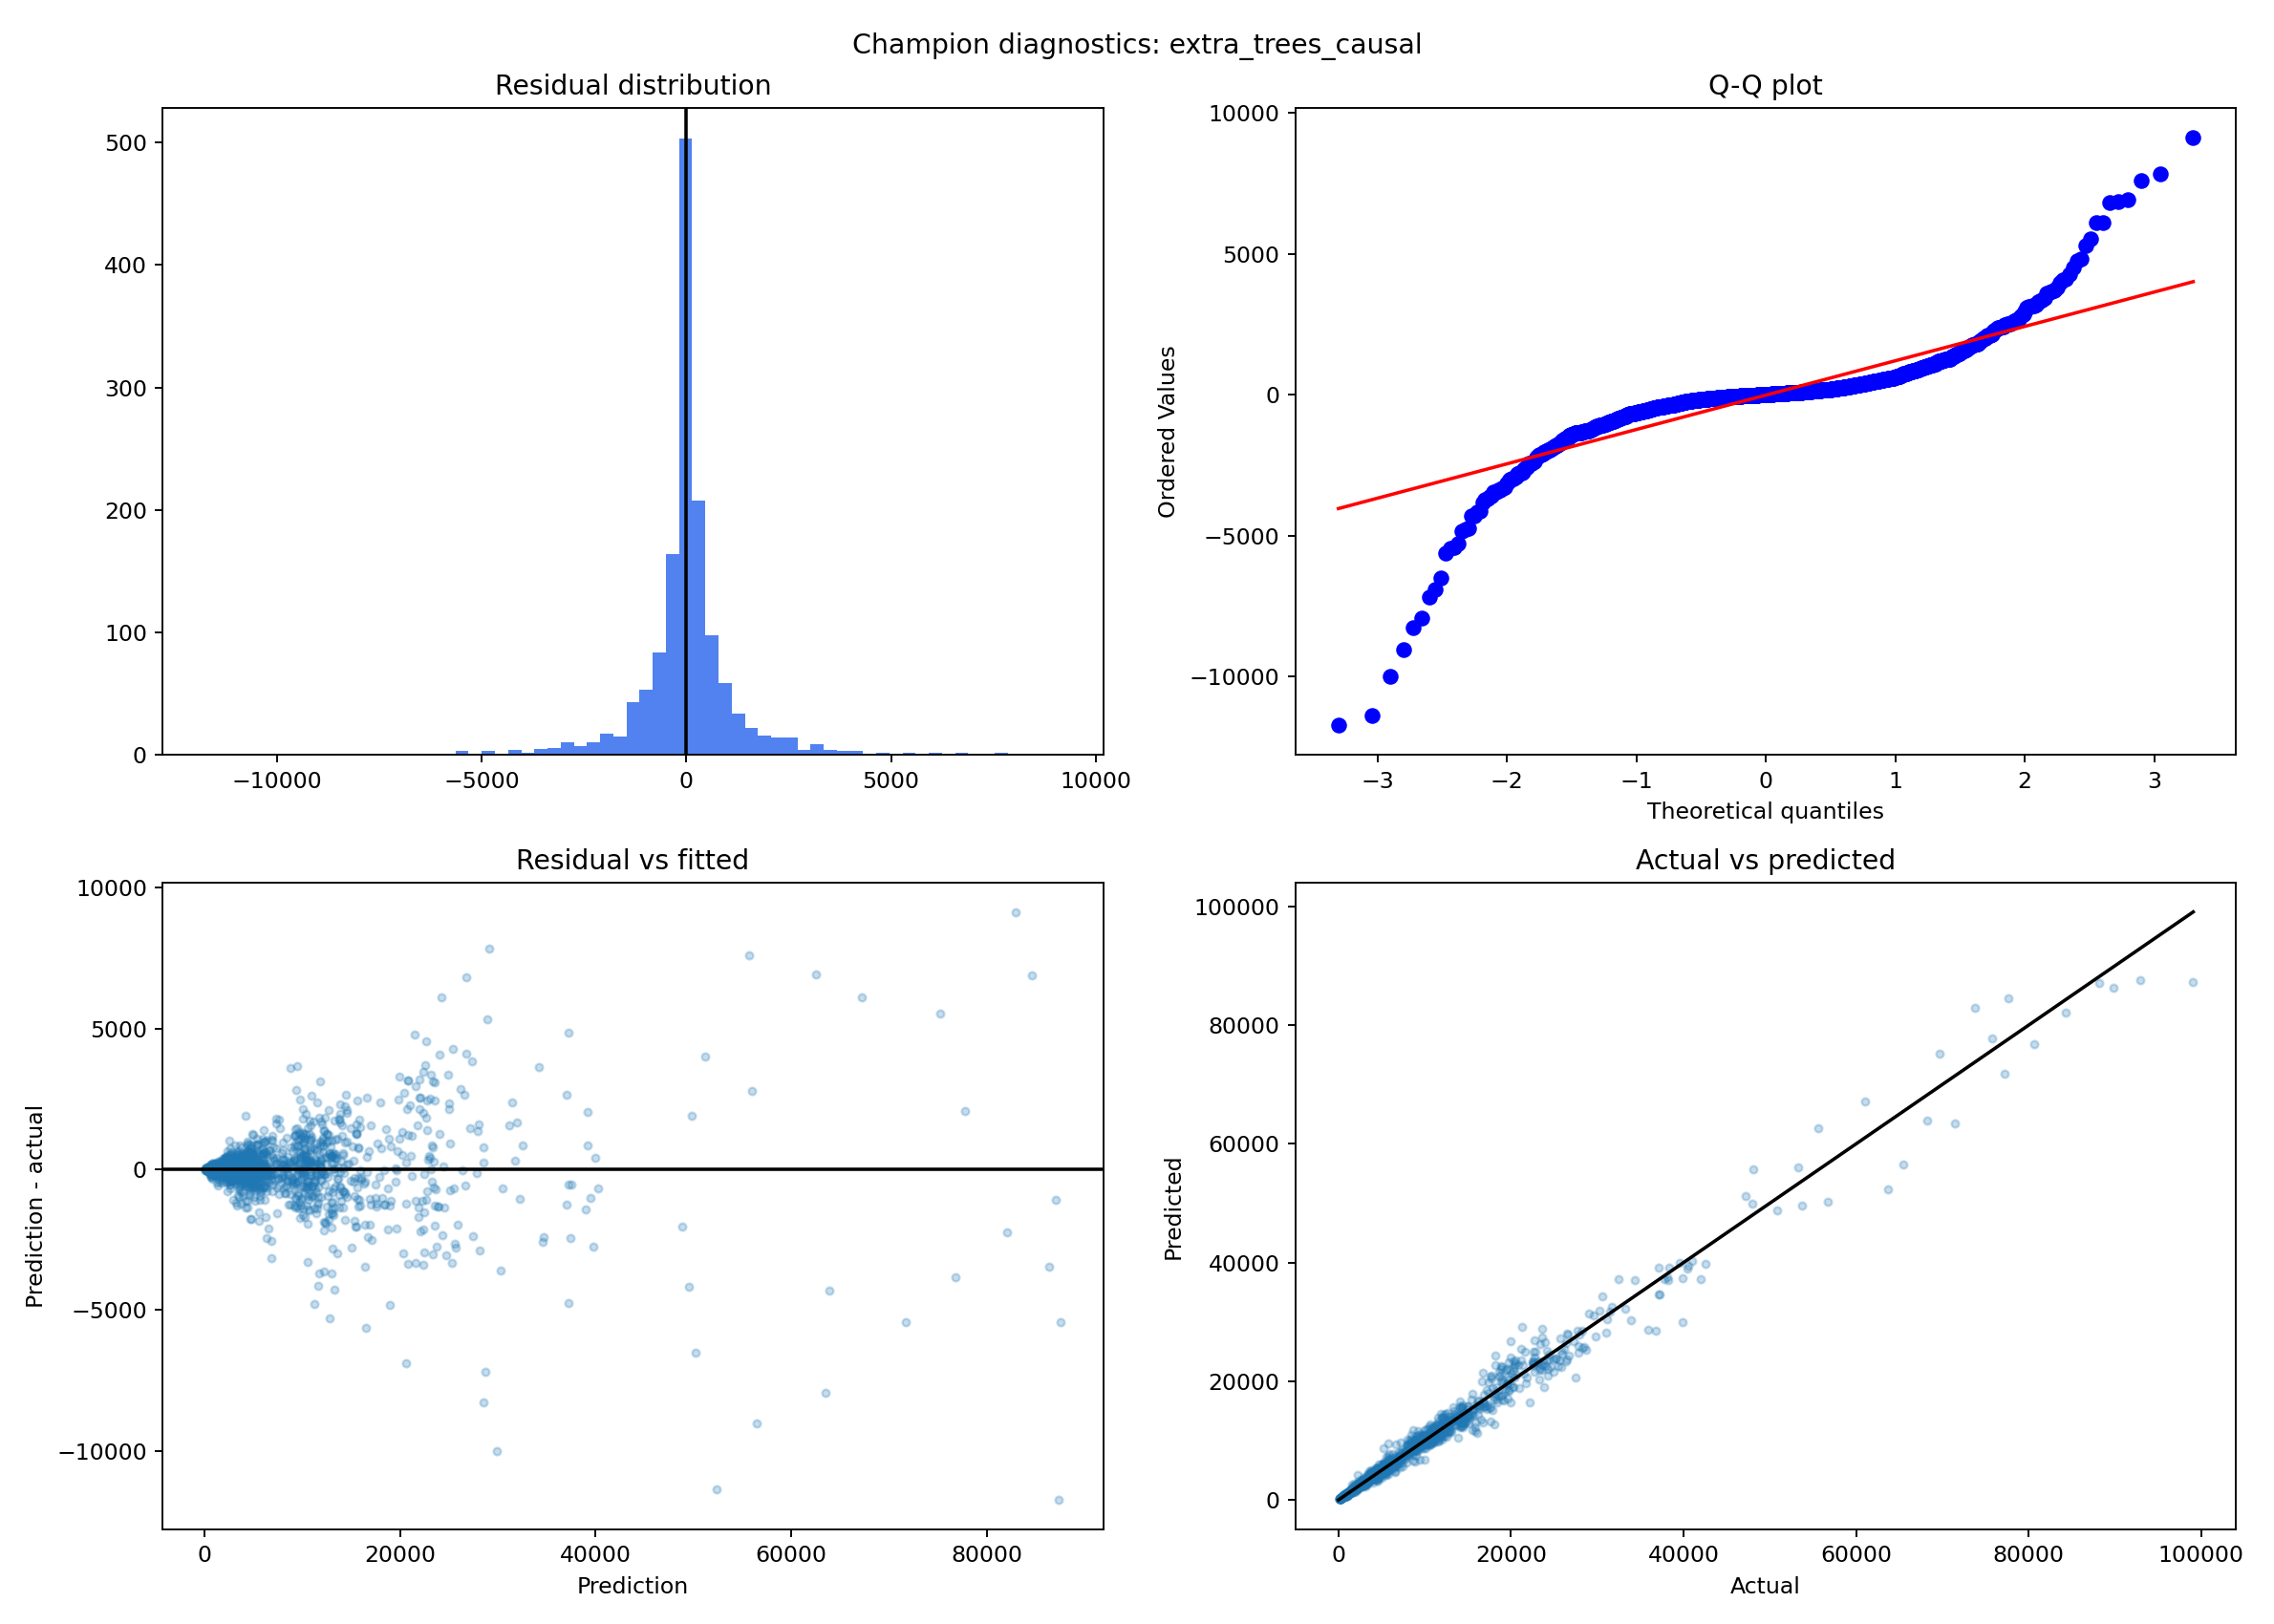

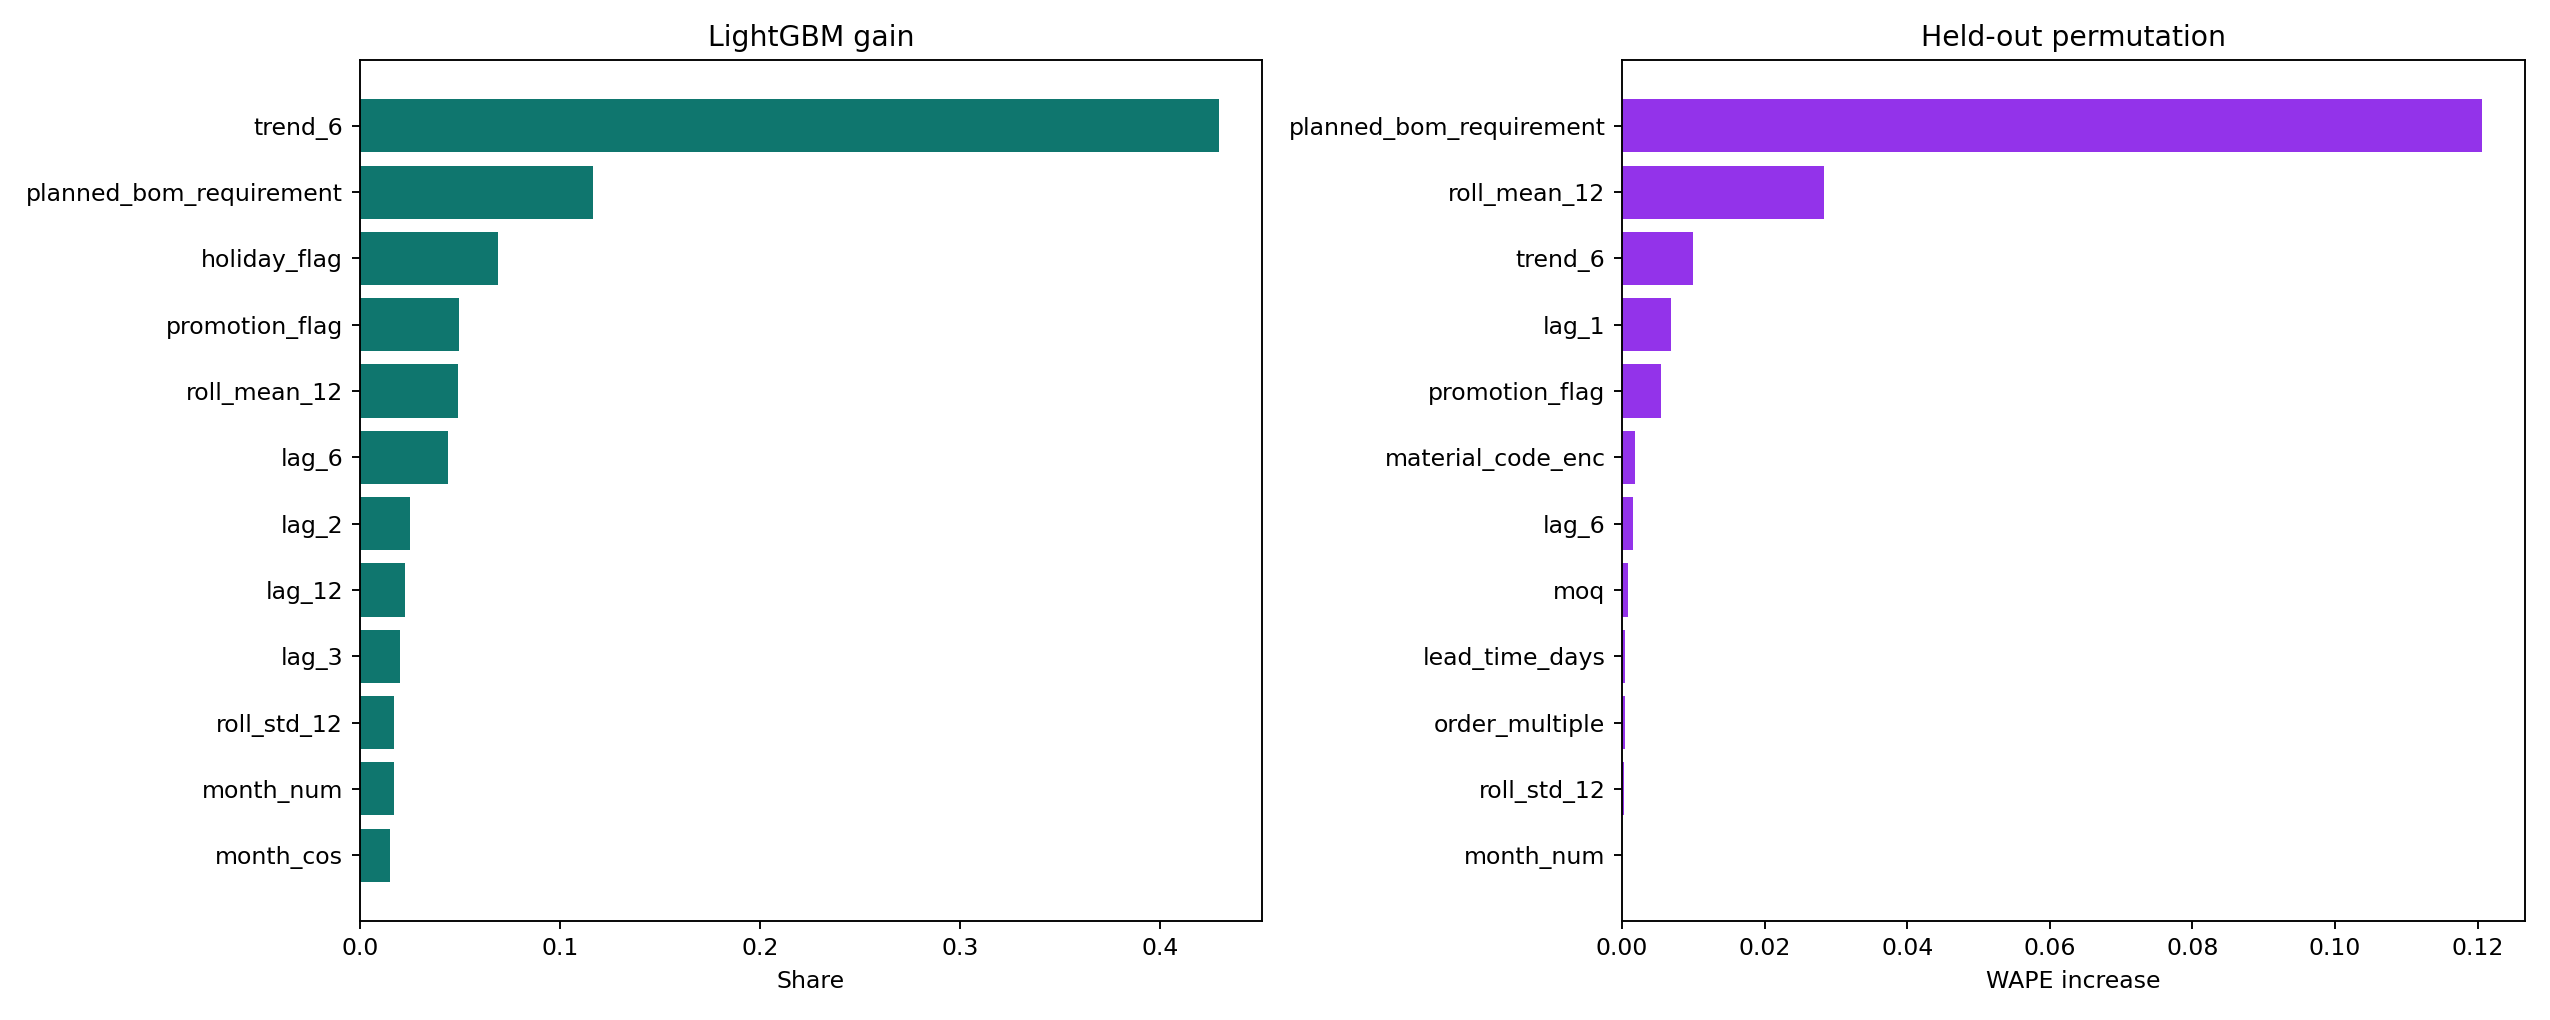

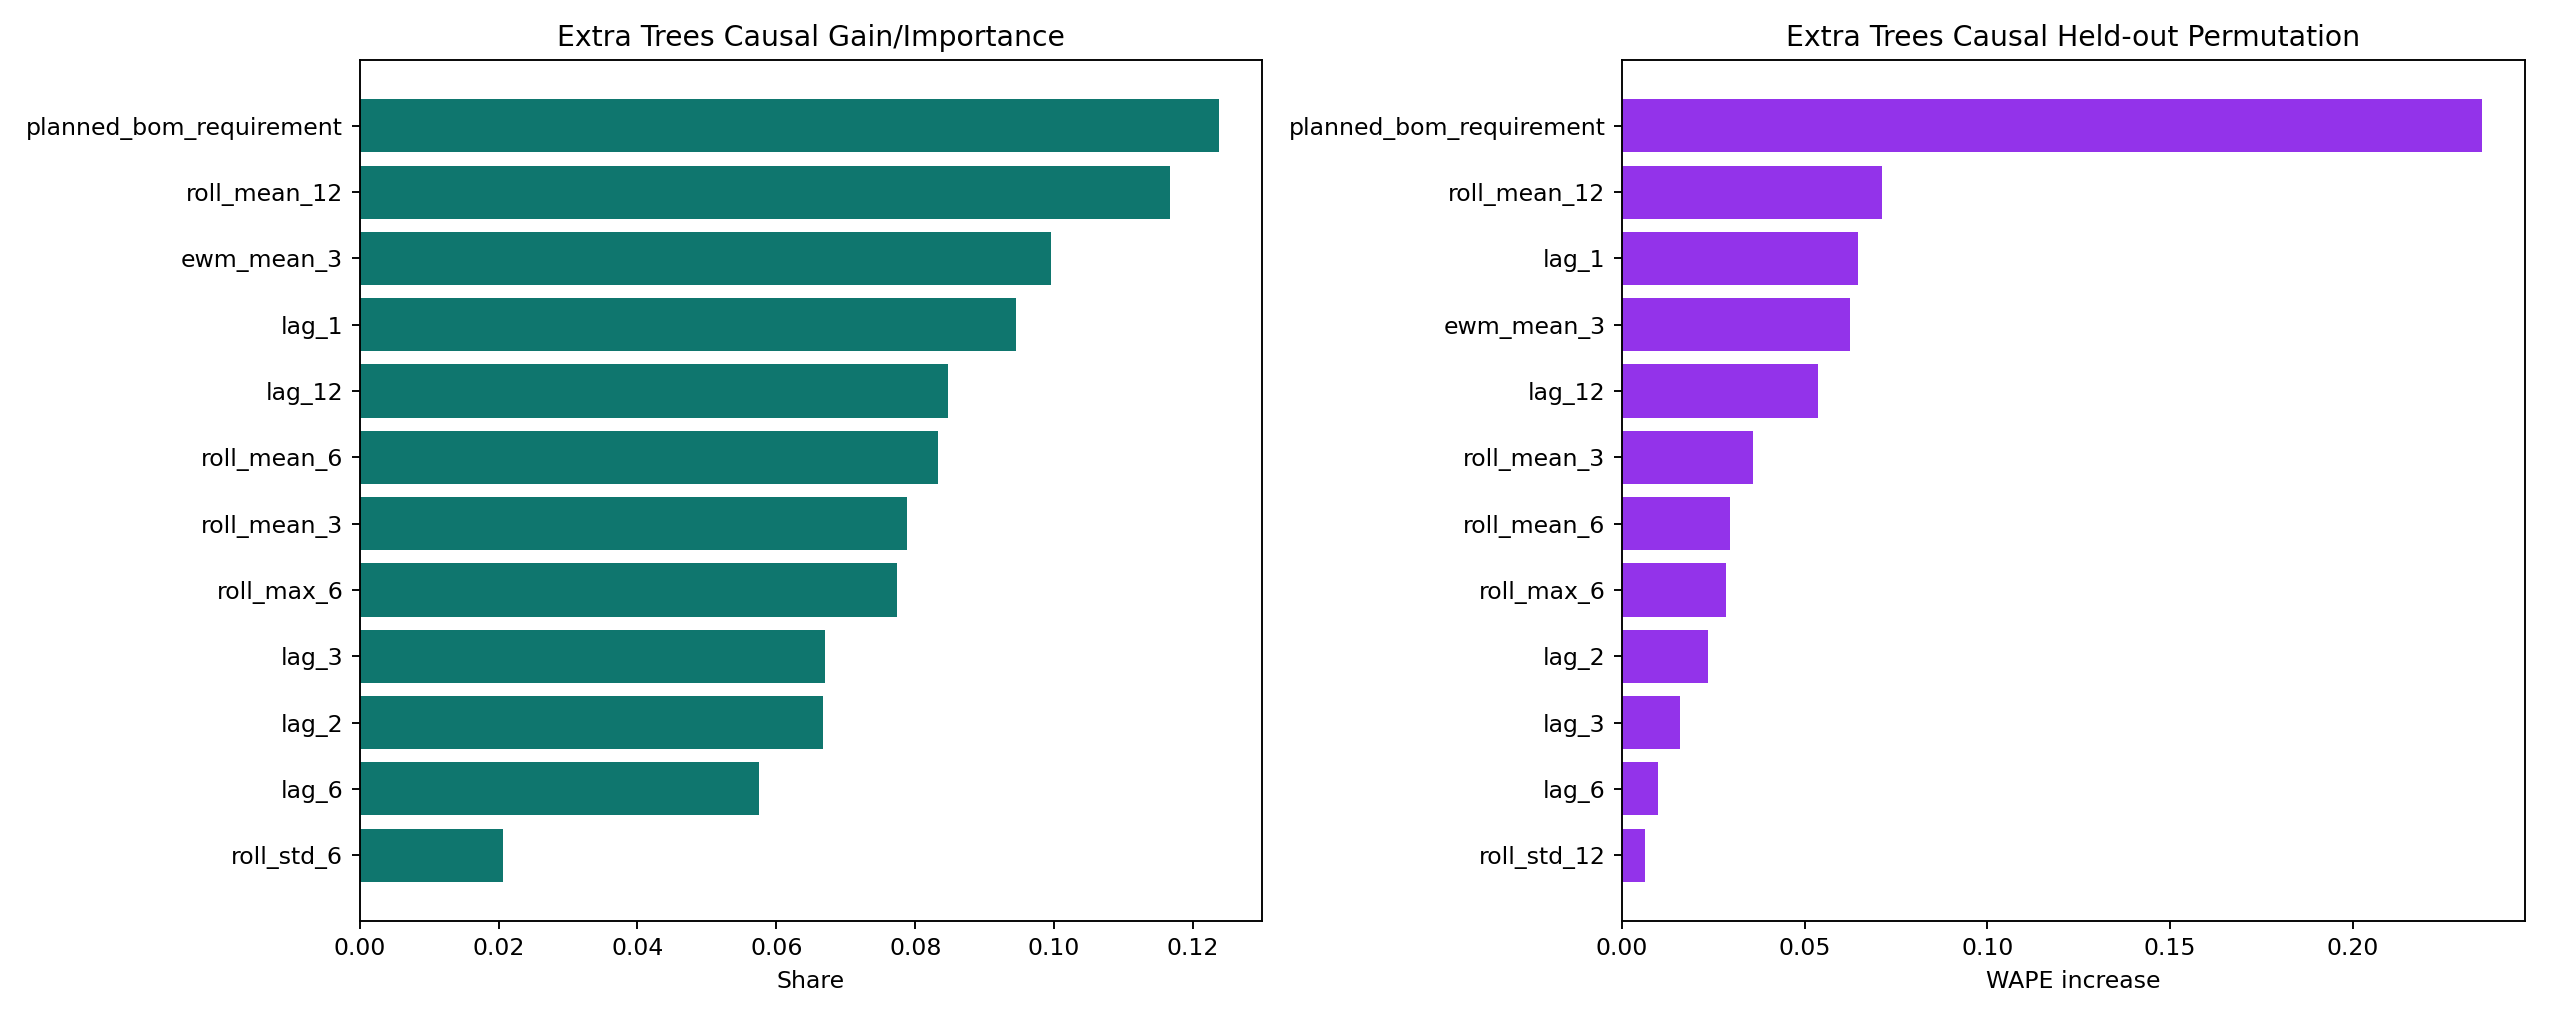

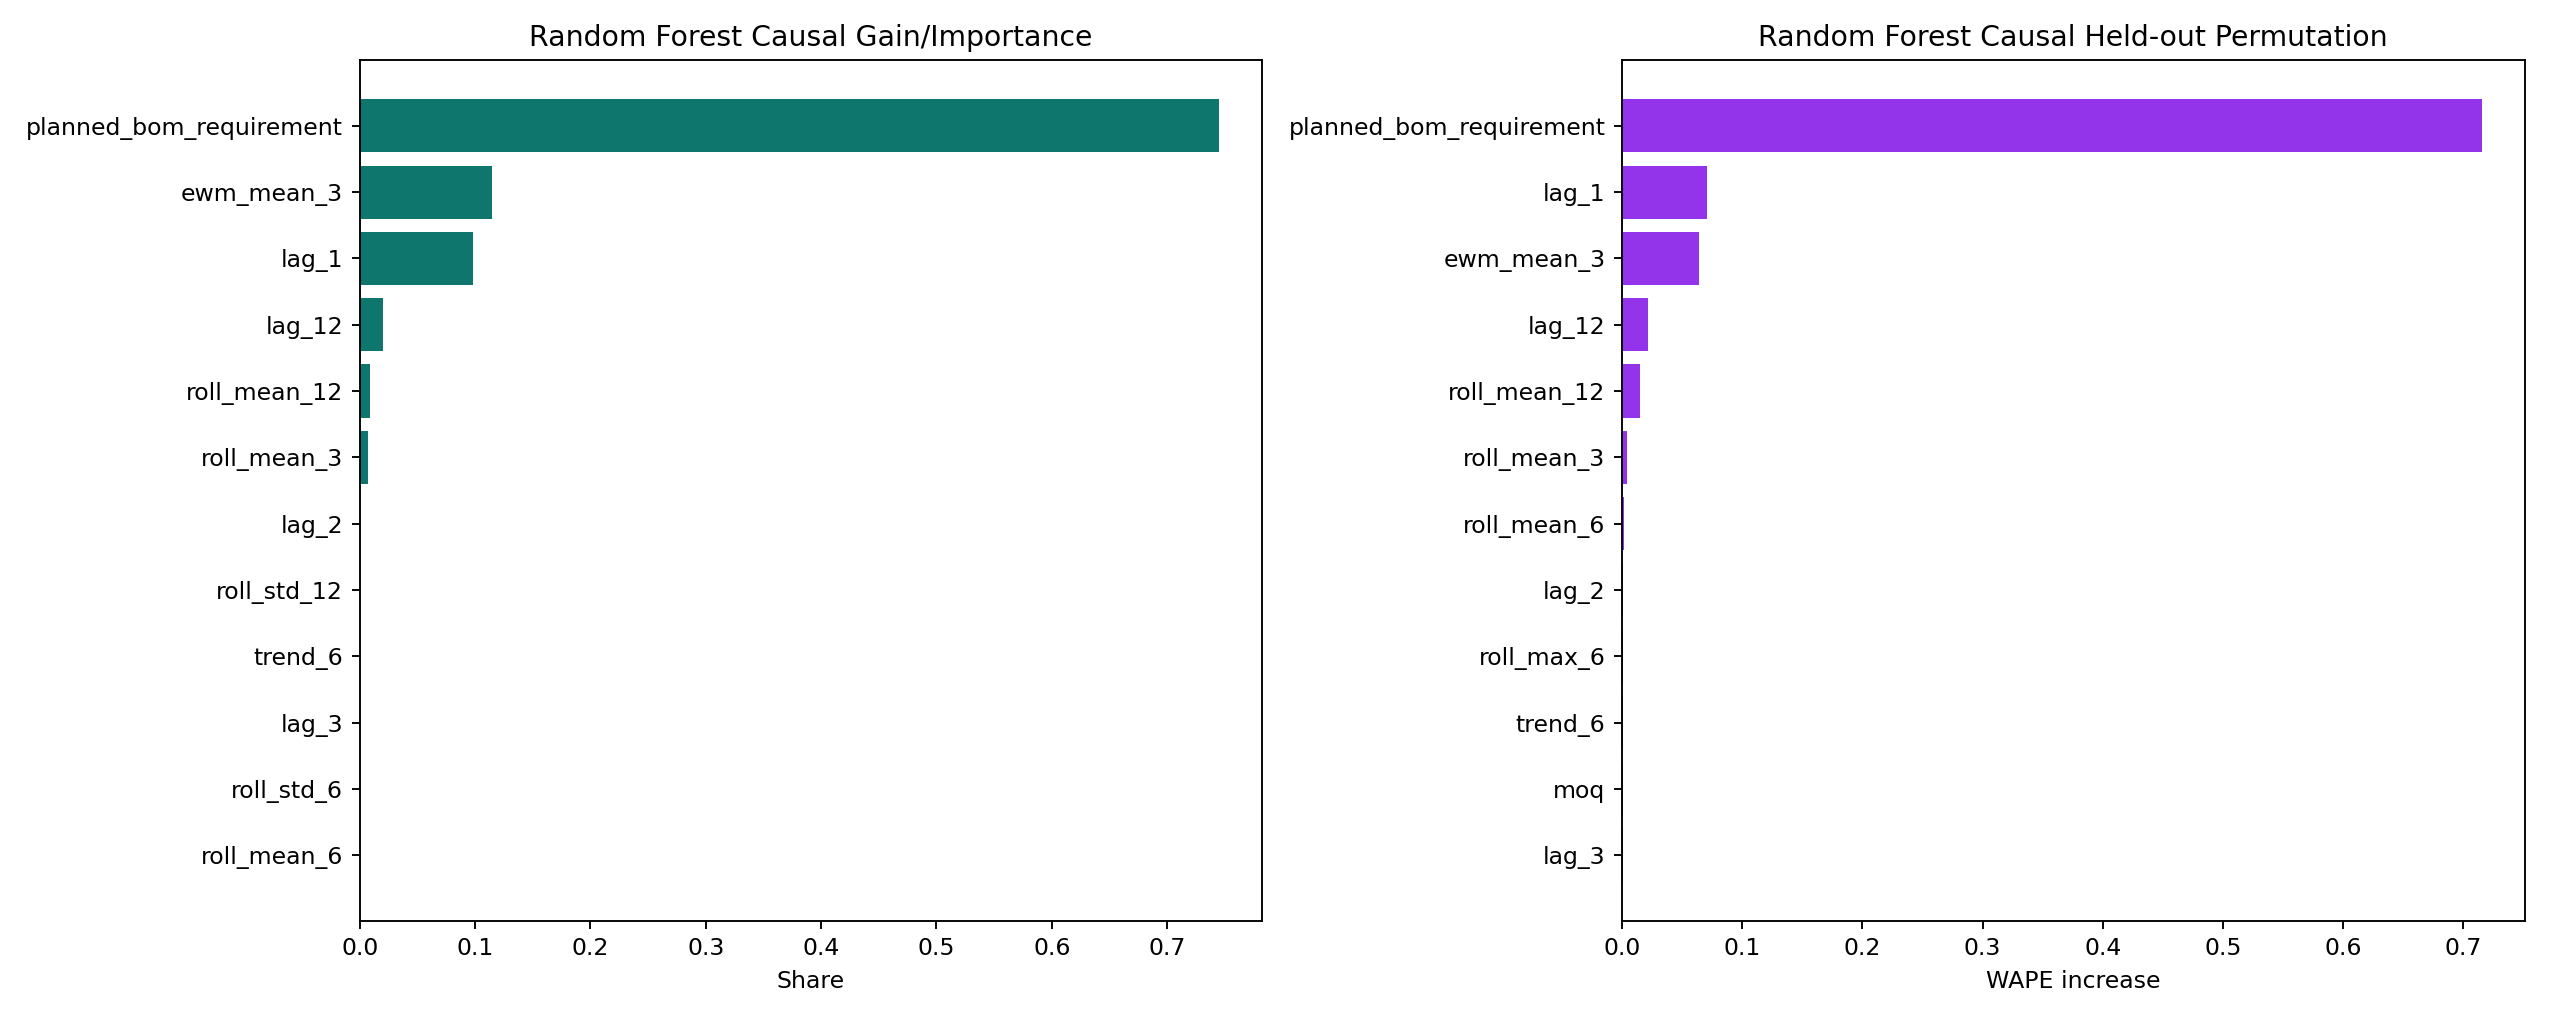

In [3]:
display(Image(filename=str(PLOTS / "02_model_leaderboard.png")))
display(Image(filename=str(PLOTS / "03_champion_residual_diagnostics.png")))
display(Image(filename=str(PLOTS / "05_feature_importance.png")))
display(Image(filename=str(PLOTS / "07_extra_trees_feature_importance.png")))
display(Image(filename=str(PLOTS / "08_random_forest_feature_importance.png")))


## 2. End-to-End Readiness

| Layer | Status | Reason |
|---|---|---|
| Controlled data generator | Ready | Reproducible seed, complete synthetic BOM and policies |
| Model/evaluation pipeline | Ready | Nested rolling protocol and diagnostics pass |
| Inventory policy simulation | Ready | MOQ/order-multiple constraints validated |
| MILP/knapsack sandbox | Ready | Policy outputs can be used in non-operational optimizer tests |
| Python production inference | Blocked | Model is fitted to generated identities and features |
| Spring canonical publication | Blocked | Synthetic rows are not operational decision evidence |
| Frontend production display | Blocked | Must not present simulation metrics as live production performance |
| Recalculate production action | Blocked for v8 | Requires a registered real-data model and atomic canonical publish job |


In [4]:
{"model_card": model_card, "deployment": deployment, "integration_contract": contract}


{'model_card': {'model_id': 'V8_CONTROLLED_EXTRA_TREES_CAUSAL',
  'display_name': 'Controlled RM/PM Causal Extra Trees',
  'model_family': 'ExtraTreesRegressor',
  'role': 'enterprise_validation_harness',
  'training_data_tier': 'CONTROLLED_SYNTHETIC_GROUND_TRUTH',
  'training_source': 'generated_fg_plan_bom_rm_pm_history',
  'synthetic_ratio': 1.0,
  'production_decision_eligible': False,
  'simulation_decision_eligible': True,
  'locked_before_test': True,
  'test_protocol': '6 tuning origins + 6 champion-selection origins + 12 untouched rolling origins',
  'test_metrics': {'model': 'extra_trees_causal',
   'rows': 1440,
   'materials': 120,
   'WAPE': 0.08335697840628727,
   'MAE': 736.7584634403185,
   'RMSE': 1408.4608905558036,
   'Bias': -0.0015093530870204453,
   'under_forecast_rate': 0.4826388888888889,
   'shock_WAPE': 0.08567139890507648},
  'interval_coverage': {'model': 'extra_trees_causal',
   'nominal_coverage': 0.9,
   'empirical_coverage': 0.9208333333333332,
   'norm

## 3. Final Conclusion

The experiment proves that the architecture and implementation can forecast a controlled RM/PM process and that production/BOM signals materially improve performance. It does not prove that v8 can forecast the real warehouse. The enterprise next step is data substitution, not another synthetic hyperparameter search: load real issue transactions, validated BOM versions and production plans into the same contract, retrain, run shadow backtests, calibrate intervals, validate inventory outcomes, and only then set `decision_eligible=true`.
